# Final Figures Actual Plotting Notebook

This notebook executes the actual plotting code copied from `plot.ipynb`. Display cells only export the newly generated source files to final `Fig*.svg`/`Fig*.tif` names and render the generated SVG in the notebook.

In [8]:
from pathlib import Path
from IPython.display import SVG, display

ROOT = Path.cwd().resolve()

from scripts.figures.final_figures import export_figure_by_name


SOURCE_OUTPUTS = {
    "Fig1A": [
        "figures/fig1_ab_clean/panel_a_clean_data_based_final.png",
        "figures/fig1_ab_clean/panel_a_clean_data_based_final.svg",
    ],
    "Fig1B": [
        "figures/fig1_ab_clean/panel_b_endpoint_valid_9x15_final.png",
        "figures/fig1_ab_clean/panel_b_endpoint_valid_9x15_final.svg",
    ],
    "Fig2": [
        "figures/Figure_raw_training_label_distribution_ecdf.jpeg",
        "figures/Figure_raw_training_label_distribution_ecdf.pdf",
        "figures/Figure_raw_training_label_distribution_ecdf.svg",
        "figures/Figure_raw_training_label_distribution_ecdf.tif",
    ],
    "Fig6": [
        "figures/Figure3_generated_pool_enrichment.jpeg",
        "figures/Figure3_generated_pool_enrichment.pdf",
        "figures/Figure3_generated_pool_enrichment.svg",
        "figures/Figure3_generated_pool_enrichment.tif",
    ],
    "Fig9": [
        "figures/Figure_MD_reassessment_surrogate_vs_md.jpeg",
        "figures/Figure_MD_reassessment_surrogate_vs_md.pdf",
        "figures/Figure_MD_reassessment_surrogate_vs_md.svg",
        "figures/Figure_MD_reassessment_surrogate_vs_md.tif",
    ],
}


def cleanup_source_outputs(name: str) -> None:
    for rel in SOURCE_OUTPUTS.get(name, []):
        path = ROOT / rel
        if path.exists():
            path.unlink()
    fig1_dir = ROOT / "figures" / "fig1_ab_clean"
    if fig1_dir.exists() and not any(fig1_dir.iterdir()):
        fig1_dir.rmdir()


def export_final_outputs_and_display_svg(name: str) -> None:
    row = export_figure_by_name(name)
    cleanup_source_outputs(name)
    print(f"{row['figure']}: {row['svg']} | {row['tif']}")
    display(SVG(filename=ROOT / row["svg"]))


def display_generated_svg(name: str) -> None:
    svg = ROOT / "figures" / f"{name}.svg"
    tif = ROOT / "figures" / f"{name}.tif"
    if not svg.exists() or not tif.exists():
        raise FileNotFoundError(f"Missing generated figure outputs for {name}: {svg}, {tif}")
    print(f"{name}: {svg.relative_to(ROOT)} | {tif.relative_to(ROOT)}")
    display(SVG(filename=svg))


## Shared Setup From `plot.ipynb`

### `plot.ipynb` Cell 0

In [9]:
# Cell 1. Imports, paths, and journal style

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()

FCD_ROOT = ROOT / "MY_PAPER_RELATED" / "MODELS" / "FCD_runs"
EVAL_DIR = FCD_ROOT / "_conductivity_eval"

SCORECARD_CSV = EVAL_DIR / "all_models_scorecard.csv"

REF_CSV = ROOT / "MY_PAPER_RELATED" / "polybert_con" / "simulation-trajectory-aggregate.csv"
REF_EMB_PATH = (
    ROOT / "MY_PAPER_RELATED" / "polybert_weighted_evidence"
    / "source_data" / "polybert_run" / "embeddings.npy"
)

OUTDIR = ROOT / "figures" / "generated_pool_enrichment"
CACHEDIR = OUTDIR / "cache"
OUTDIR.mkdir(parents=True, exist_ok=True)
CACHEDIR.mkdir(parents=True, exist_ok=True)

TIMES_FONT_DIR = Path("/usr/share/fonts/truetype/msttcorefonts")
for font_path in TIMES_FONT_DIR.glob("Times_New_Roman*.ttf"):
    font_manager.fontManager.addfont(str(font_path))

AVAILABLE_FONTS = {font.name for font in font_manager.fontManager.ttflist}
JOURNAL_FONT = next(
    (font for font in ["Liberation Sans", "Nimbus Sans", "Arial"] if font in AVAILABLE_FONTS),
    "DejaVu Sans",
)

plt.rcParams.update({
    "font.family": JOURNAL_FONT,
    "font.serif": [JOURNAL_FONT, "Liberation Sans", "Nimbus Sans"],
    "font.sans-serif": [JOURNAL_FONT, "Liberation Sans", "Nimbus Sans", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

MODEL_NAME_MAP = {
    "TransCVAE": "SELFIES-PSMILES TransCVAE",
    "TransCVAE_PSMILES": "PSMILES TransCVAE",
    "LSTM_CVAE_PSMILES": "PSMILES LSTM-CVAE",
    "minGPT": "minGPT",
}

MODEL_ORDER = [
    "SELFIES-PSMILES TransCVAE",
    "PSMILES TransCVAE",
    "PSMILES LSTM-CVAE",
    "minGPT",
]

MODEL_COLORS = {
    "SELFIES-PSMILES TransCVAE": "#008b8b",
    "PSMILES TransCVAE": "#1f5fd0",
    "PSMILES LSTM-CVAE": "#ff7f0e",
    "minGPT": "#7f7f7f",
}

TARGET_MAP = {
    "LOW": "lower target",
    "HIGH": "top-tail target",
}

TARGET_MARKERS = {
    "lower target": "o",
    "top-tail target": "^",
}

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_panel_label(ax, label):
    ax.text(
        -0.12, 1.04, label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="right",
        va="bottom",
    )

def assert_exists(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return path

for p in [SCORECARD_CSV, REF_CSV]:
    assert_exists(p)

print("ROOT:", ROOT)
print("SCORECARD_CSV:", SCORECARD_CSV)
print("REF_CSV:", REF_CSV)
print("REF_EMB_PATH:", REF_EMB_PATH)

ROOT: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE
SCORECARD_CSV: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/MODELS/FCD_runs/_conductivity_eval/all_models_scorecard.csv
REF_CSV: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/polybert_con/simulation-trajectory-aggregate.csv
REF_EMB_PATH: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/polybert_weighted_evidence/source_data/polybert_run/embeddings.npy


### `plot.ipynb` Cell 1

In [10]:
# Cell 2. PolyBERT-Ridge utilities matched to your repo script

def to_psmiles(s: str) -> str:
    if not isinstance(s, str):
        return ""
    tmp = s.replace("[*]", "__STAR__")
    tmp = tmp.replace("*", "[*]")
    tmp = tmp.replace("__STAR__", "[*]")
    return tmp

def pick_smiles_col(frame: pd.DataFrame) -> str:
    for c in ("SMILES", "smiles", "mol_smiles", "p_smiles", "psmiles", "PSMILES"):
        if c in frame.columns:
            return c
    raise ValueError(f"No SMILES-like column found. columns={frame.columns.tolist()}")

def load_reference_training_data():
    df = pd.read_csv(REF_CSV).copy()
    required = {"SMILES", "CONDUCTIVITY"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Reference CSV missing columns: {missing}")

    df["PSMILES"] = df["SMILES"].map(to_psmiles)
    y = np.log10(df["CONDUCTIVITY"].astype(float).to_numpy())
    return df, y

def get_polybert_encoder(device="cuda"):
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("kuelumbus/polyBERT", device=device)

def load_or_compute_reference_embeddings(ref_df, encoder, batch_size=64):
    if REF_EMB_PATH.exists():
        X = np.load(REF_EMB_PATH)
        if X.shape[0] != len(ref_df):
            raise ValueError(
                f"Reference embedding row mismatch: {X.shape[0]} embeddings vs {len(ref_df)} rows"
            )
        return X

    REF_EMB_PATH.parent.mkdir(parents=True, exist_ok=True)
    X = encoder.encode(
        ref_df["PSMILES"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    np.save(REF_EMB_PATH, X)
    return X

def fit_polybert_ridge(device="cuda", batch_size=64, ridge_alpha=1.0):
    ref_df, y = load_reference_training_data()
    encoder = get_polybert_encoder(device=device)
    X = load_or_compute_reference_embeddings(ref_df, encoder, batch_size=batch_size)

    reg = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=ridge_alpha, random_state=42)),
    ])
    reg.fit(X, y)
    return encoder, reg

def predict_log10_conductivity(smiles, encoder, reg, batch_size=64):
    psmiles = pd.Series(smiles).astype(str).map(to_psmiles).tolist()
    emb = encoder.encode(
        psmiles,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    pred = reg.predict(emb).astype(float)
    return pred

def read_generated_smiles_csv(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path).copy()
    smiles_col = pick_smiles_col(frame)

    # Same endpoint artifact exclusion used in your repo script
    frame = frame.loc[
        ~frame[smiles_col].astype(str).str.contains("[*][*]", regex=False, na=False)
    ].copy()

    frame = frame.drop_duplicates(subset=[smiles_col]).copy()
    frame = frame.rename(columns={smiles_col: "SMILES"})
    return frame[["SMILES"]].reset_index(drop=True)

### `plot.ipynb` Cell 2

In [11]:
# Cell 3. Build or load per-sample PolyBERT predictions for proposed SELFIES-PSMILES TransCVAE

PRED_CACHE = CACHEDIR / "proposed_transcvae_polybert_predictions.csv"
PRECOMPUTED_PRED_FILES = {
    "LOW": ROOT / "MY_PAPER_RELATED" / "polybert_con" / "TransCVAE" / "all_novel_smiles_condz_low_with_pred_conductivity.csv",
    "HIGH": ROOT / "MY_PAPER_RELATED" / "polybert_con" / "TransCVAE" / "all_novel_smiles_condz_high_with_pred_conductivity.csv",
}

def pick_prediction_log10_col(frame: pd.DataFrame) -> str:
    for c in ("pred_log10_sigma", "pred_log10_cond", "log10_pred_cond", "mean_log10_cond"):
        if c in frame.columns:
            return c

    for c in ("pred_cond", "conductivity_for_summary", "CONDUCTIVITY"):
        if c in frame.columns:
            cond = pd.to_numeric(frame[c], errors="coerce")
            frame["pred_log10_sigma"] = np.log10(cond.clip(lower=np.finfo(float).tiny))
            return "pred_log10_sigma"

    raise ValueError(f"No prediction column found. columns={frame.columns.tolist()}")

def load_precomputed_proposed_prediction_table(write_cache=True):
    missing = [path for path in PRECOMPUTED_PRED_FILES.values() if not path.exists()]
    if missing:
        print("Precomputed PolyBERT prediction files not found; falling back to recomputation.")
        for path in missing:
            print("  missing:", path)
        return None

    all_rows = []
    for condition, csv_path in PRECOMPUTED_PRED_FILES.items():
        frame = pd.read_csv(csv_path).copy()
        smiles_col = pick_smiles_col(frame)
        pred_col = pick_prediction_log10_col(frame)

        tmp = frame.rename(columns={smiles_col: "SMILES"}).copy()
        tmp["pred_log10_sigma"] = pd.to_numeric(tmp[pred_col], errors="coerce")
        tmp = tmp.dropna(subset=["SMILES", "pred_log10_sigma"]).copy()
        tmp = tmp.drop_duplicates(subset=["SMILES"]).copy()

        tmp["model"] = "SELFIES-PSMILES TransCVAE"
        tmp["condition"] = condition
        tmp["target_setting"] = TARGET_MAP[condition]
        tmp["repeat"] = "precomputed_all_novel"
        tmp["hit_1e4"] = tmp["pred_log10_sigma"] >= -4.0

        keep_cols = [
            "SMILES",
            "model",
            "condition",
            "target_setting",
            "repeat",
            "pred_log10_sigma",
            "hit_1e4",
        ]
        keep_cols += [
            c for c in ("prediction_source", "polybert_exact_available")
            if c in tmp.columns
        ]
        all_rows.append(tmp[keep_cols])

        print(
            f"Loaded precomputed {TARGET_MAP[condition]} predictions:",
            csv_path,
            "n =", len(tmp),
            "hit =", tmp["hit_1e4"].mean(),
            "mean =", tmp["pred_log10_sigma"].mean(),
        )

    pred_df = pd.concat(all_rows, ignore_index=True)
    if write_cache:
        pred_df.to_csv(PRED_CACHE, index=False)
        print(f"Saved normalized cache: {PRED_CACHE}")
    return pred_df

def get_transcvae_source_csvs():
    rows = []

    for condition, cond_dir in [("LOW", "condz_low"), ("HIGH", "condz_high")]:
        base = FCD_ROOT / "TransCVAE" / cond_dir
        if not base.exists():
            raise FileNotFoundError(f"Missing TransCVAE condition directory: {base}")

        for repeat_dir in sorted(base.glob("repeat_*")):
            csv_path = repeat_dir / f"all_novel_smiles_{cond_dir}.csv"
            if csv_path.exists():
                rows.append({
                    "condition": condition,
                    "target_setting": TARGET_MAP[condition],
                    "repeat": repeat_dir.name,
                    "csv_path": csv_path,
                })

    source_df = pd.DataFrame(rows)
    if source_df.empty:
        raise RuntimeError("No TransCVAE generated source CSVs found.")
    return source_df

def build_proposed_prediction_table(device="cuda", batch_size=64, force_recompute=False):
    if PRED_CACHE.exists() and not force_recompute:
        pred_df = pd.read_csv(PRED_CACHE)
        print(f"Loaded cached predictions: {PRED_CACHE}")
        return pred_df

    if not force_recompute:
        pred_df = load_precomputed_proposed_prediction_table(write_cache=True)
        if pred_df is not None:
            return pred_df

    source_df = get_transcvae_source_csvs()
    display(source_df)

    try:
        encoder, reg = fit_polybert_ridge(device=device, batch_size=batch_size, ridge_alpha=1.0)
    except OSError as exc:
        raise RuntimeError(
            "Could not load kuelumbus/polyBERT from Hugging Face. "
            "Use the local *_with_pred_conductivity.csv files, populate PRED_CACHE, "
            "or authenticate with Hugging Face before setting force_recompute=True."
        ) from exc

    all_rows = []
    for _, row in source_df.iterrows():
        frame = read_generated_smiles_csv(row["csv_path"])

        pred_log10 = predict_log10_conductivity(
            frame["SMILES"],
            encoder=encoder,
            reg=reg,
            batch_size=batch_size,
        )

        tmp = frame.copy()
        tmp["model"] = "SELFIES-PSMILES TransCVAE"
        tmp["condition"] = row["condition"]
        tmp["target_setting"] = row["target_setting"]
        tmp["repeat"] = row["repeat"]
        tmp["pred_log10_sigma"] = pred_log10
        tmp["hit_1e4"] = tmp["pred_log10_sigma"] >= -4.0
        all_rows.append(tmp)

        print(
            row["target_setting"],
            row["repeat"],
            "n =", len(tmp),
            "hit =", tmp["hit_1e4"].mean(),
            "mean =", tmp["pred_log10_sigma"].mean(),
        )

    pred_df = pd.concat(all_rows, ignore_index=True)
    pred_df.to_csv(PRED_CACHE, index=False)
    print(f"Saved: {PRED_CACHE}")
    return pred_df

# GPU가 없으면 device="cpu"로 바꿔라.
pred_pool_df = build_proposed_prediction_table(
    device="cuda",
    batch_size=64,
    force_recompute=False,
)

pred_pool_df.groupby("target_setting").agg(
    n=("pred_log10_sigma", "size"),
    mean=("pred_log10_sigma", "mean"),
    median=("pred_log10_sigma", "median"),
    hit_1e4=("hit_1e4", "mean"),
)


Loaded cached predictions: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/generated_pool_enrichment/cache/proposed_transcvae_polybert_predictions.csv


,n,mean,median,hit_1e4
target_setting,,,,
lower target,44999,-4.519774,-4.535644,0.0028
top-tail target,2126,-3.097806,-3.062960,1.0000


### `plot.ipynb` Cell 3

In [12]:
# Cell 4. Load scorecard and construct Panel B/C dataframe from actual repo summary

score = pd.read_csv(SCORECARD_CSV).copy()

keep_models = list(MODEL_NAME_MAP.keys())
tradeoff_df = score.loc[
    score["model"].isin(keep_models) & score["condition"].isin(["LOW", "HIGH"])
].copy()

tradeoff_df["display_model"] = tradeoff_df["model"].map(MODEL_NAME_MAP)
tradeoff_df["target_setting"] = tradeoff_df["condition"].map(TARGET_MAP)

tradeoff_df = tradeoff_df.rename(columns={
    "all_novel_unique_mean": "anu_yield",
    "fcd_mean": "fcd",
    "hit_1e4_mean": "hit_fraction",
})

tradeoff_df = tradeoff_df[
    ["model", "display_model", "condition", "target_setting", "anu_yield", "fcd", "hit_fraction"]
].copy()

tradeoff_df = tradeoff_df.sort_values(
    by=["display_model", "target_setting"],
    key=lambda s: s.map({m: i for i, m in enumerate(MODEL_ORDER)}).fillna(s)
)

display(tradeoff_df)

# 네가 figure prompt에 쓴 핵심값들이 실제 scorecard와 맞는지 확인
check = tradeoff_df.loc[
    tradeoff_df["target_setting"].eq("top-tail target"),
    ["display_model", "anu_yield", "hit_fraction", "fcd"]
]
display(check)

,model,display_model,condition,target_setting,anu_yield,fcd,hit_fraction
11,TransCVAE,SELFIES-PSMILES TransCVAE,LOW,lower target,41994.4,2.417261,0.007201
4,TransCVAE,SELFIES-PSMILES TransCVAE,HIGH,top-tail target,8729.2,16.531677,0.998098
12,TransCVAE_PSMILES,PSMILES TransCVAE,LOW,lower target,24370.6,3.172375,0.004850
5,TransCVAE_PSMILES,PSMILES TransCVAE,HIGH,top-tail target,15607.6,17.068145,0.983406
10,LSTM_CVAE_PSMILES,PSMILES LSTM-CVAE,LOW,lower target,18102.6,0.731583,0.003590
3,LSTM_CVAE_PSMILES,PSMILES LSTM-CVAE,HIGH,top-tail target,10.0,23.337894,1.000000
13,minGPT,minGPT,LOW,lower target,28940.6,0.506427,0.067760
6,minGPT,minGPT,HIGH,top-tail target,10846.4,0.419704,0.369212


,display_model,anu_yield,hit_fraction,fcd
4,SELFIES-PSMILES TransCVAE,8729.2,0.998098,16.531677
5,PSMILES TransCVAE,15607.6,0.983406,17.068145
3,PSMILES LSTM-CVAE,10.0,1.000000,23.337894
6,minGPT,10846.4,0.369212,0.419704


## Fig1A

### Actual plotting code from `plot.ipynb` Cell 8

Loaded: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/polybert_con/simulation-trajectory-aggregate.csv
Shape: (6270, 11)
SMILES_COL: SMILES
COND_COL: CONDUCTIVITY
log10 sigma range: -5.605548319173784 -2.8041003475907664
Top 5% cutoff: -3.8927900303521317
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/fig1_ab_clean/panel_a_clean_data_based_final.png
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/fig1_ab_clean/panel_a_clean_data_based_final.svg


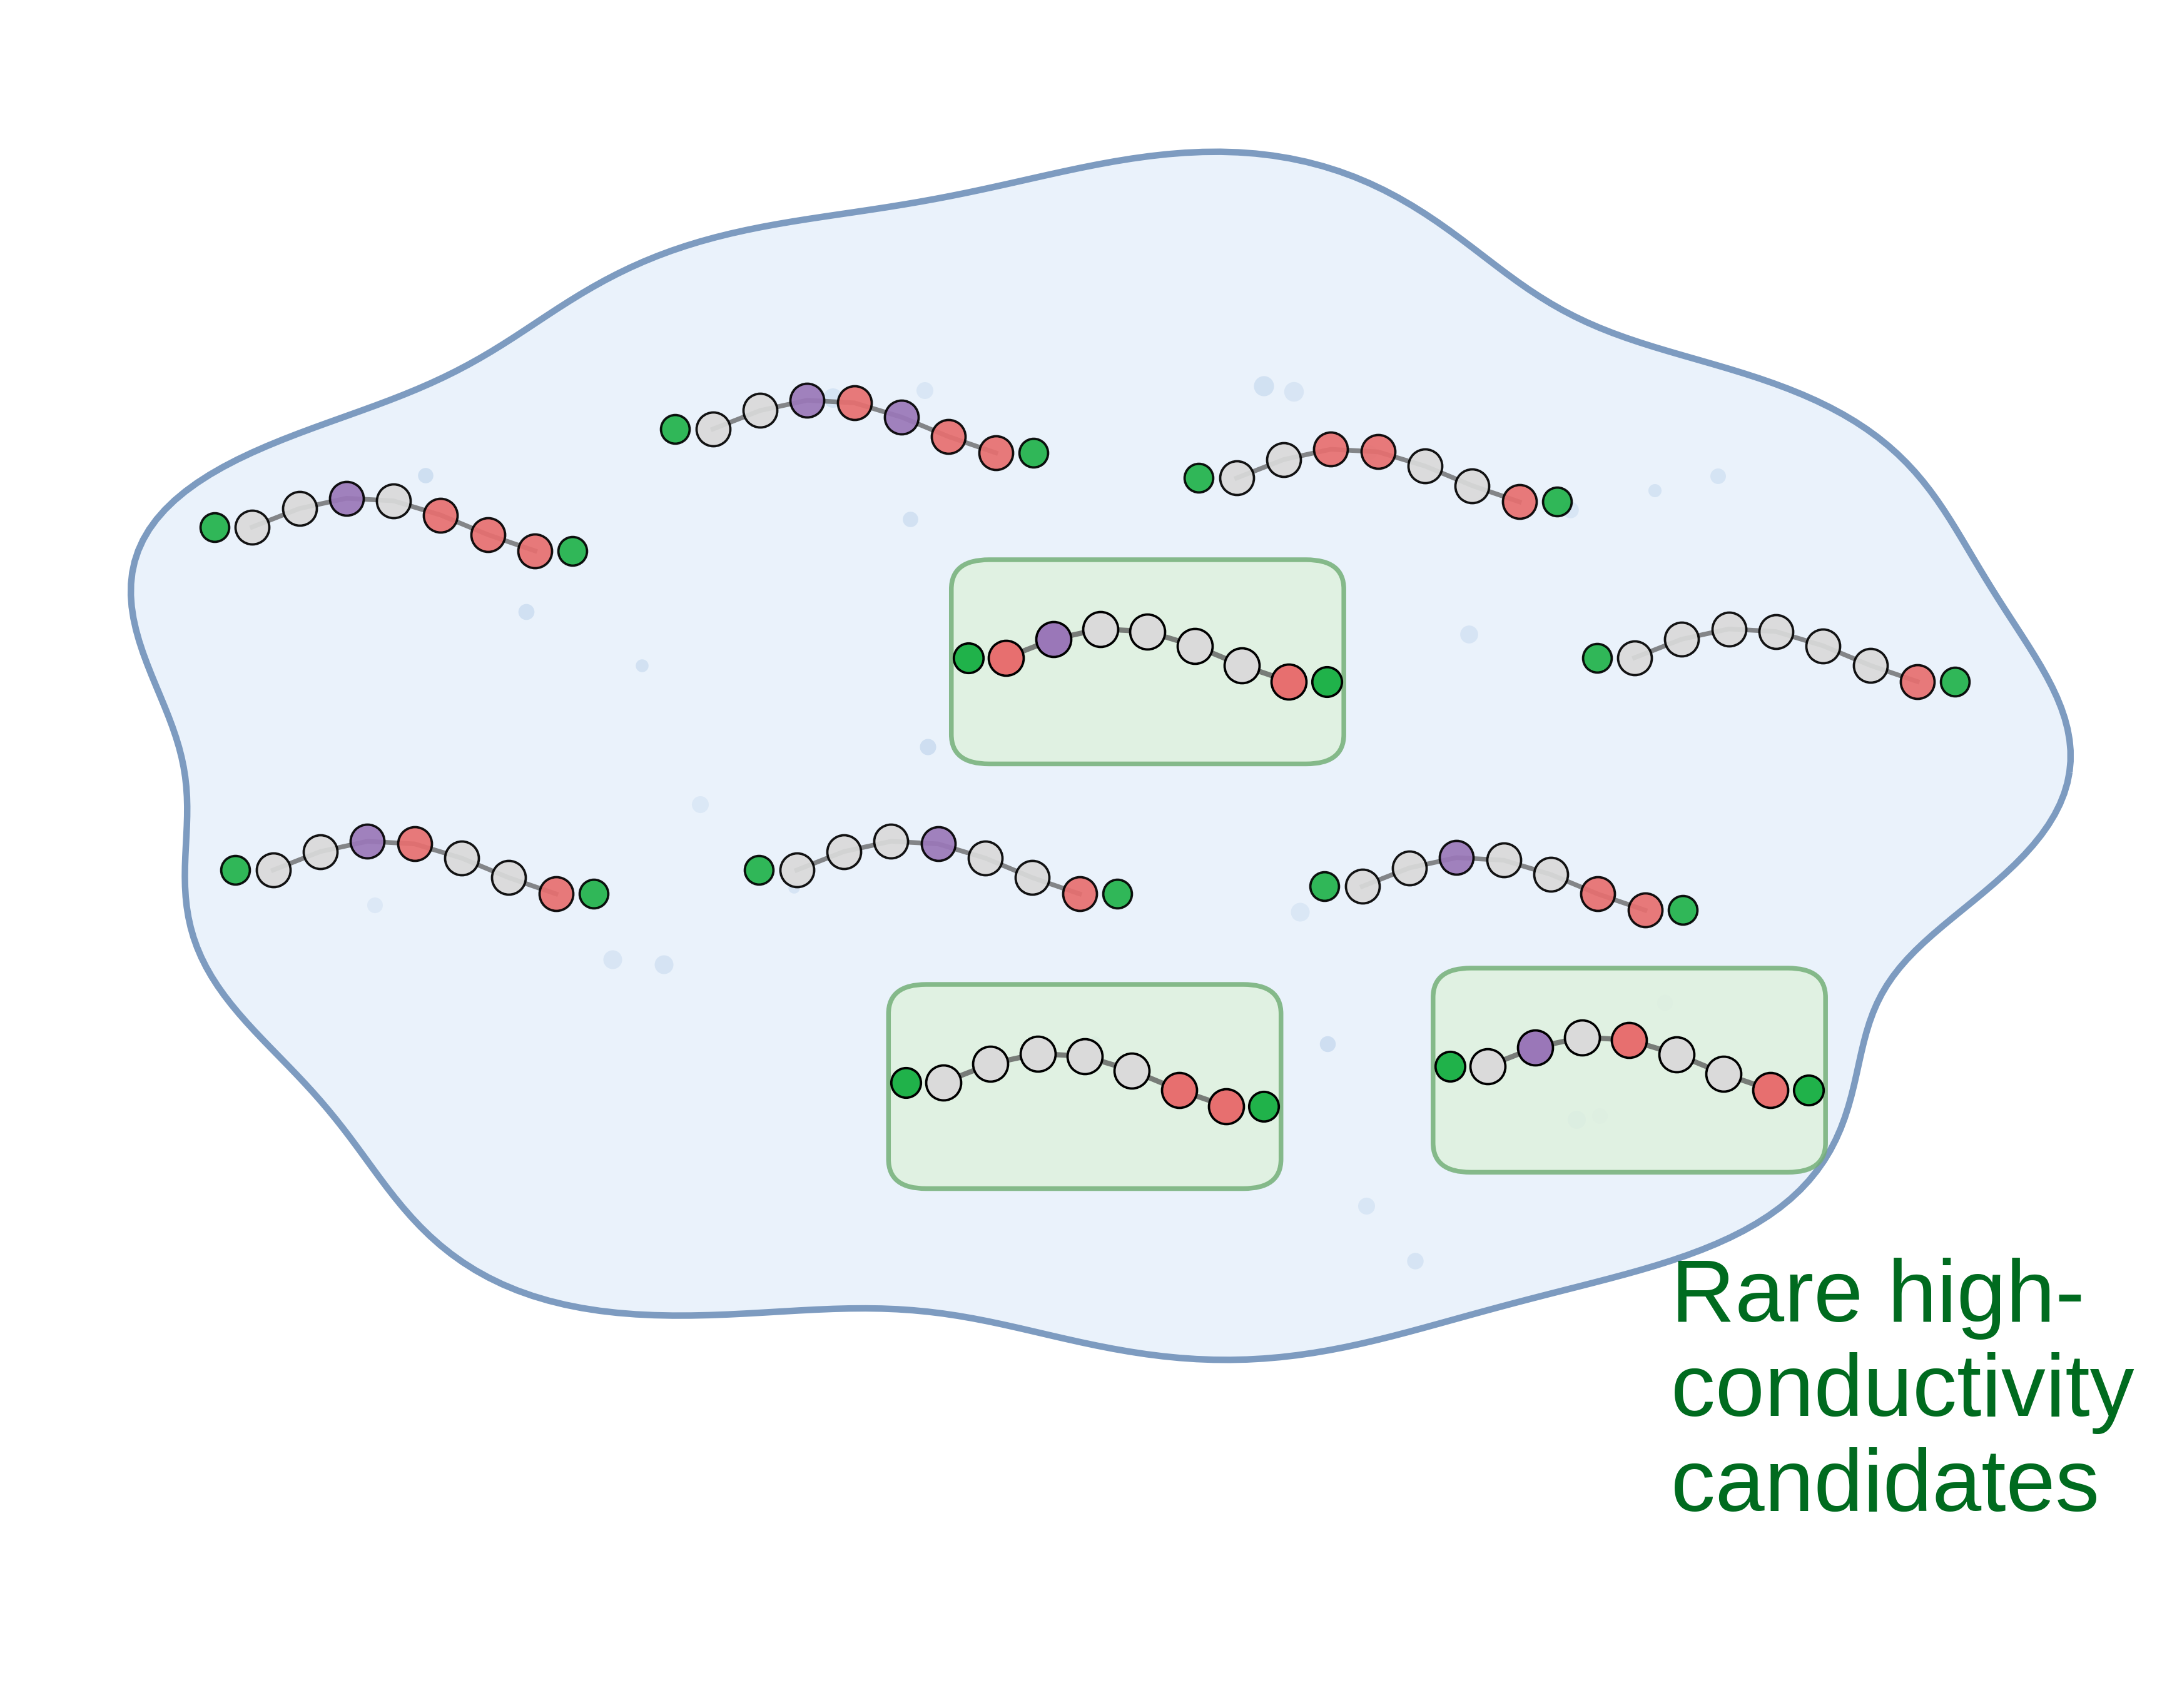

In [13]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, PathPatch
from matplotlib.path import Path

# ============================================================
# 0. Load data
# ============================================================

CSV_CANDIDATES = [
    ROOT / "MY_PAPER_RELATED" / "polybert_con" / "simulation-trajectory-aggregate.csv",
    ROOT / "simulation-trajectory-aggregate.csv",
    ROOT / "data" / "simulation-trajectory-aggregate.csv",
]

REF_CSV = next((p for p in CSV_CANDIDATES if p.exists()), None)
if REF_CSV is None:
    raise FileNotFoundError("simulation-trajectory-aggregate.csv not found. Set REF_CSV manually.")

OUT_DIR = ROOT / "figures" / "fig1_ab_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(REF_CSV).copy()
print("Loaded:", REF_CSV)
print("Shape:", df.shape)

# ============================================================
# 1. Column detection
# ============================================================
def norm_col(c):
    return re.sub(r"[^a-z0-9]+", "", str(c).lower())

def find_smiles_col(df):
    preferred = [
        "psmiles", "p_smiles", "p-smiles", "polymer_smiles",
        "smiles", "pSMILES", "P_SMILES"
    ]
    norm_map = {norm_col(c): c for c in df.columns}

    for p in preferred:
        if norm_col(p) in norm_map:
            return norm_map[norm_col(p)]

    obj_cols = df.select_dtypes(include=["object"]).columns
    best, score = None, -1
    for c in obj_cols:
        s = df[c].astype(str)
        n_star = s.str.contains(r"\*", regex=True, na=False).sum()
        if n_star > score:
            best, score = c, n_star

    if best is None or score <= 0:
        raise ValueError("Could not detect pSMILES/SMILES column.")
    return best

def find_cond_col(df):
    candidates = []
    for c in df.columns:
        nc = norm_col(c)
        if any(k in nc for k in ["conductivity", "conduct", "sigma"]):
            x = pd.to_numeric(df[c], errors="coerce")
            if x.notna().sum() > 10:
                candidates.append(c)

    if candidates:
        log_cols = [c for c in candidates if "log" in norm_col(c)]
        return log_cols[0] if log_cols else candidates[0]

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    scored = []
    for c in numeric_cols:
        x = pd.to_numeric(df[c], errors="coerce").dropna()
        if len(x) < 10:
            continue
        med = float(np.median(x))
        score = 0
        if -12 < med < 2:
            score += 2
        if 1e-12 < med < 1e-1:
            score += 3
        scored.append((score, c))

    scored.sort(reverse=True)
    if not scored or scored[0][0] <= 0:
        raise ValueError("Could not detect conductivity column. Set COND_COL manually.")
    return scored[0][1]

SMILES_COL = find_smiles_col(df)
COND_COL = find_cond_col(df)

print("SMILES_COL:", SMILES_COL)
print("COND_COL:", COND_COL)

def to_log_sigma(x, colname):
    x = pd.to_numeric(x, errors="coerce")
    nc = norm_col(colname)

    if "log" in nc or np.nanmedian(x) < 0:
        return x
    return np.log10(x.where(x > 0))

df["_psmiles"] = df[SMILES_COL].astype(str).str.replace("[*]", "*", regex=False)
df["_endpoint_count"] = df["_psmiles"].str.count(r"\*")
df["_log_sigma"] = to_log_sigma(df[COND_COL], COND_COL)

df_valid = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["_log_sigma"]).copy()

TOP_Q = 0.95
top_cut = df_valid["_log_sigma"].quantile(TOP_Q)

print("log10 sigma range:", df_valid["_log_sigma"].min(), df_valid["_log_sigma"].max())
print("Top 5% cutoff:", top_cut)

# ============================================================
# 2. Style helpers
# ============================================================

COL = {
    "blue_fill": "#EAF2FB",
    "blue_edge": "#7D9BC0",
    "hist_blue": "#B8D2EA",
    "hist_blue_edge": "#8FB3D3",
    "green_fill": "#DFF1DE",
    "green_edge": "#74AF78",
    "green_text": "#006B1F",
    "black": "#111111",
}

ATOM_COL = {
    "C": "#DADADA",
    "O": "#E76F6F",
    "N": "#9A77B8",
    "S": "#D8B449",
    "P": "#D99A36",
    "F": "#63B87A",
    "Cl": "#58B9C4",
    "Br": "#B87949",
    "*": "#20B24A",
    "X": "#CFCFCF",
}

def atom_tokens_from_psmiles(s):
    s = str(s).replace("[*]", "*")
    toks = re.findall(r"Br|Cl|\*|[A-Z][a-z]?|[a-z]", s)
    out = []
    for t in toks:
        if t == "*":
            out.append("*")
        elif t in ["Br", "Cl"]:
            out.append(t)
        elif t.islower():
            out.append(t.upper())
        else:
            out.append(t)
    return out

def reduced_atom_tokens(s, max_atoms=7):
    toks = atom_tokens_from_psmiles(s)
    atoms = [t for t in toks if t != "*"]

    if len(atoms) == 0:
        atoms = ["C", "O", "C"]

    if len(atoms) > max_atoms:
        idx = np.linspace(0, len(atoms) - 1, max_atoms).round().astype(int)
        atoms = [atoms[i] for i in idx]

    return atoms

def draw_chain_icon(
    ax,
    x,
    y,
    w,
    psmiles,
    endpoint_mode="both",
    high=False,
    alpha=1.0,
    lw=1.0,
    node_size=72,
    transform=None,
    zorder=5,
):
    if transform is None:
        transform = ax.transAxes

    atoms = reduced_atom_tokens(psmiles, max_atoms=7)
    n = len(atoms)

    xs = np.linspace(x - w / 2, x + w / 2, n)
    ys = y + 0.018 * np.sin(np.linspace(0, np.pi * 1.3, n))

    if high:
        bg = FancyBboxPatch(
            (x - w * 0.62, y - 0.055),
            w * 1.24,
            0.105,
            boxstyle="round,pad=0.010,rounding_size=0.018",
            facecolor=COL["green_fill"],
            edgecolor=COL["green_edge"],
            linewidth=0.9,
            alpha=0.85,
            transform=transform,
            zorder=zorder - 2,
        )
        ax.add_patch(bg)

    ax.plot(
        xs, ys,
        color="#555555",
        linewidth=lw,
        alpha=0.75 * alpha,
        transform=transform,
        zorder=zorder,
    )

    for xi, yi, atom in zip(xs, ys, atoms):
        ax.scatter(
            xi, yi,
            s=node_size,
            color=ATOM_COL.get(atom, ATOM_COL["X"]),
            edgecolors="black",
            linewidths=0.45,
            alpha=alpha,
            transform=transform,
            zorder=zorder + 1,
        )

    if endpoint_mode == "both":
        ep_x = [xs[0] - 0.018, xs[-1] + 0.018]
        ep_y = [ys[0], ys[-1]]
    elif endpoint_mode == "one":
        ep_x = [xs[0] - 0.018]
        ep_y = [ys[0]]
    elif endpoint_mode == "internal":
        mid = n // 2
        ep_x = [xs[mid]]
        ep_y = [ys[mid] + 0.028]
    else:
        ep_x, ep_y = [], []

    if ep_x:
        ax.scatter(
            ep_x, ep_y,
            s=node_size * 0.72,
            color=ATOM_COL["*"],
            edgecolors="black",
            linewidths=0.45,
            alpha=alpha,
            transform=transform,
            zorder=zorder + 2,
        )

# ============================================================
# 3. Cloud patch (구름만 더 크게)
# ============================================================
def cloud_patch(ax):
    theta = np.linspace(0, 2 * np.pi, 360)
    r = 1.0 + 0.045 * np.sin(5 * theta + 0.4) + 0.030 * np.sin(9 * theta + 2.0)

    # 구름만 더 크게
    cx, cy = 0.50, 0.55
    rx, ry = 0.45, 0.36

    x = cx + rx * r * np.cos(theta)
    y = cy + ry * r * np.sin(theta)

    verts = np.column_stack([x, y])
    codes = np.full(len(verts), Path.LINETO)
    codes[0] = Path.MOVETO

    patch = PathPatch(
        Path(verts, codes),
        facecolor=COL["blue_fill"],
        edgecolor=COL["blue_edge"],
        linewidth=1.25,
        transform=ax.transAxes,
        zorder=0,
    )
    ax.add_patch(patch)

    rng = np.random.default_rng(5)
    for _ in range(32):
        px = rng.uniform(0.12, 0.88)
        py = rng.uniform(0.25, 0.82)

        if ((px - cx) / rx) ** 2 + ((py - cy) / ry) ** 2 < 0.92:
            ax.scatter(
                px, py,
                s=rng.uniform(5, 15),
                color="#9BBCE0",
                alpha=rng.uniform(0.16, 0.36),
                linewidths=0,
                transform=ax.transAxes,
                zorder=1,
            )

# ============================================================
# 4. Sampling for schematic
# ============================================================
def sample_smiles_for_panel_a(df_valid, n_low=7, n_high=3, seed=23):
    endpoint_df = df_valid[df_valid["_endpoint_count"] == 2].copy()
    if endpoint_df.empty:
        endpoint_df = df_valid.copy()

    high = endpoint_df[endpoint_df["_log_sigma"] >= top_cut]
    low = endpoint_df[endpoint_df["_log_sigma"] < top_cut]

    low_sample = low.sample(min(n_low, len(low)), random_state=seed)
    high_sample = high.sample(min(n_high, len(high)), random_state=seed + 1)

    return low_sample["_psmiles"].tolist(), high_sample["_psmiles"].tolist()

# ============================================================
# 5. Panel A
# ============================================================
def plot_panel_a_clean(df_valid, save=True):
    low_smis, high_smis = sample_smiles_for_panel_a(
        df_valid,
        n_low=7,
        n_high=3,
        seed=23,
    )

    fig = plt.figure(figsize=(7.2, 8.2), dpi=600)
    gs = fig.add_gridspec(
        2, 1,
        height_ratios=[2.35, 1.0],
        hspace=0.035,
    )

    ax_top = fig.add_subplot(gs[0])

    ax_top.set_axis_off()
    ax_top.set_xlim(0, 1)
    ax_top.set_ylim(0, 1)


    cloud_patch(ax_top)

    low_pos = [
        (0.17, 0.70),
        (0.39, 0.76),
        (0.64, 0.73),
        (0.83, 0.62),
        (0.18, 0.49),
        (0.43, 0.49),
        (0.70, 0.48),
    ]

    high_pos = [
        (0.53, 0.62),
        (0.50, 0.36),  # 아래 가운데 박스: 위로 이동
        (0.76, 0.37),  # 아래 오른쪽 박스: 위로 + 약간 왼쪽으로 이동
    ]

    for smi, (x, y) in zip(low_smis, low_pos):
        draw_chain_icon(
            ax_top, x, y, 0.135, smi,
            endpoint_mode="both",
            high=False,
            alpha=0.92,
            node_size=42,
            lw=0.9,
        )

    for smi, (x, y) in zip(high_smis, high_pos):
        draw_chain_icon(
            ax_top, x, y, 0.135, smi,
            endpoint_mode="both",
            high=True,
            alpha=1.0,
            node_size=45,
            lw=1.0,
        )

    ax_top.text(
        0.78, 0.17,
        "Rare high-\nconductivity\ncandidates",
        color=COL["green_text"],
        fontsize=17,
        ha="left",
        va="center",
        transform=ax_top.transAxes,
    )

    if save:
        png = OUT_DIR / "panel_a_clean_data_based_final.png"
        svg = OUT_DIR / "panel_a_clean_data_based_final.svg"

        fig.savefig(png, dpi=600, bbox_inches="tight")
        fig.savefig(svg, bbox_inches="tight")
        print("Saved:", png)
        print("Saved:", svg)

    return fig

# ============================================================
# 6. Run
# ============================================================
fig_a = plot_panel_a_clean(df_valid, save=True)
plt.show()

Fig1A: figures/Fig1A.svg | figures/Fig1A.tif


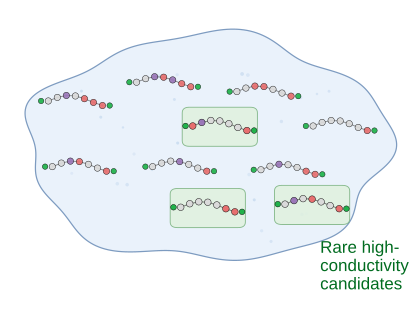

In [14]:
export_final_outputs_and_display_svg("Fig1A")

## Fig1B

### Actual plotting code from `plot.ipynb` Cell 9

In [15]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

OUT_DIR = Path("figures/fig1_ab_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "panel_b_endpoint_valid_9x15_final.png"
OUT_SVG = OUT_DIR / "panel_b_endpoint_valid_9x15_final.svg"


def draw_token_string(ax, cx, y, n=7, spacing=0.052, s=105):
    colors = ["#D9EAF7", "#E7E7E7", "#D6EED2", "#EBDDB9", "#DDD4EF", "#E7E7E7", "#D9EAF7"]
    xs = cx + (np.arange(n) - (n - 1) / 2) * spacing

    ax.plot(
        xs, [y] * n,
        color="0.35",
        lw=1.25,
        transform=ax.transAxes,
        zorder=3,
    )

    for i, x in enumerate(xs):
        ax.scatter(
            x, y,
            s=s,
            color=colors[i % len(colors)],
            edgecolors="black",
            linewidths=0.65,
            transform=ax.transAxes,
            zorder=4,
        )

def draw_repeat_unit(ax, cx, y, mode="both", scale=1.0, valid=True):
    xs = np.array([-0.165, -0.082, 0.000, 0.082, 0.165]) * scale + cx
    ys = np.array([0.000, 0.020, 0.045, 0.018, 0.000]) * scale + y

    atom_cols = ["#E76F6F", "#DADADA", "#DADADA", "#DADADA", "#DADADA"]

    ax.plot(
        xs, ys,
        color="0.52" if valid else "0.62",
        lw=1.7,
        alpha=1.0 if valid else 0.68,
        transform=ax.transAxes,
        zorder=4,
    )

    for x, yy, c in zip(xs, ys, atom_cols):
        ax.scatter(
            x, yy,
            s=82 * scale,
            color=c,
            edgecolors="black",
            linewidths=0.6,
            alpha=1.0 if valid else 0.65,
            transform=ax.transAxes,
            zorder=6,
        )

    if mode == "both":
        ep = [
            (xs[0] - 0.045 * scale, ys[0] + 0.008 * scale),
            (xs[-1] + 0.045 * scale, ys[-1] + 0.008 * scale),
        ]
    elif mode == "one":
        ep = [(xs[0] - 0.045 * scale, ys[0] + 0.008 * scale)]
    elif mode == "internal":
        ep = [(xs[2], ys[2] + 0.070 * scale)]
    else:
        ep = []

    for x, yy in ep:
        ax.scatter(
            x, yy,
            s=82 * scale,
            color="#20B24A",
            edgecolors="black",
            linewidths=0.6,
            alpha=1.0 if valid else 0.75,
            transform=ax.transAxes,
            zorder=7,
        )

def plot_panel_b_9x15(out_png=OUT_PNG, out_svg=OUT_SVG):
    # 9:15 세로 비율
    fig, ax = plt.subplots(figsize=(6.0, 10.0), dpi=300)

    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # =========================
    # Top: molecular strings box
    # =========================
    box_x, box_y, box_w, box_h = 0.12, 0.705, 0.76, 0.245

    blue_box = FancyBboxPatch(
        (box_x, box_y),
        box_w,
        box_h,
        boxstyle="round,pad=0.018,rounding_size=0.035",
        facecolor="#EAF2FB",
        edgecolor="#7D9BC0",
        linewidth=1.8,
        transform=ax.transAxes,
        zorder=0,
    )
    ax.add_patch(blue_box)

    ax.text(
        0.50, 0.905,
        "Molecular strings",
        ha="center",
        va="center",
        fontsize=20,
        transform=ax.transAxes,
    )

    for y in [0.835, 0.790, 0.745]:
        draw_token_string(ax, 0.50, y)

    # ... 상자 안쪽으로 확실히 배치
    ax.text(
        0.50, 0.715,
        "...",
        ha="center",
        va="center",
        fontsize=21,
        transform=ax.transAxes,
    )

    # Downward arrow
    ax.annotate(
        "",
        xy=(0.50, 0.635),
        xytext=(0.50, 0.690),
        xycoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="->",
            lw=2.2,
            color="black",
        ),
    )

    # =========================
    # Decoded repeat units
    # =========================
    ax.text(
        0.50, 0.595,
        "Decoded repeat units",
        ha="center",
        va="center",
        fontsize=22,
        transform=ax.transAxes,
    )

    row_y = [0.515, 0.405, 0.295, 0.185]

    modes = ["both", "one", "none", "internal"]
    labels = [
        "endpoint-valid",
        "one endpoint lost",
        "both endpoints lost",
        "misplaced endpoint",
    ]
    valids = [True, False, False, False]

    for y, mode, label, valid in zip(row_y, modes, labels, valids):
        draw_repeat_unit(
            ax,
            cx=0.35,
            y=y,
            mode=mode,
            scale=1.05,
            valid=valid,
        )

        if valid:
            ax.text(
                0.62, y + 0.020,
                label,
                color="#006B1F",
                fontsize=18,
                ha="left",
                va="center",
                transform=ax.transAxes,
            )
        else:
            ax.text(
                0.59, y + 0.020,
                "×",
                color="#CC2020",
                fontsize=30,
                fontweight="bold",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

            ax.text(
                0.65, y + 0.020,
                label,
                color="0.35",
                fontsize=15.5,
                ha="left",
                va="center",
                transform=ax.transAxes,
            )

    # =========================
    # Bottom message box
    # =========================
    note_x, note_y, note_w, note_h = 0.06, 0.035, 0.88, 0.095

    note_box = FancyBboxPatch(
        (note_x, note_y),
        note_w,
        note_h,
        boxstyle="round,pad=0.012,rounding_size=0.020",
        facecolor="#FFF3D7",
        edgecolor="#C99D3B",
        linewidth=1.7,
        transform=ax.transAxes,
        zorder=0,
    )
    ax.add_patch(note_box)

    ax.text(
        0.50,
        note_y + note_h / 2,
        "Molecular validity ≠ polymer usability",
        ha="center",
        va="center",
        fontsize=15.8,
        fontweight="bold",
        transform=ax.transAxes,
    )

    fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
    fig.show()
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    fig.savefig(out_svg, bbox_inches="tight")
    

    print("Saved:", out_png)
    print("Saved:", out_svg)

    return fig

fig_b = plot_panel_b_9x15()
plt.show()

Saved: figures/fig1_ab_clean/panel_b_endpoint_valid_9x15_final.png
Saved: figures/fig1_ab_clean/panel_b_endpoint_valid_9x15_final.svg


Fig1B: figures/Fig1B.svg | figures/Fig1B.tif


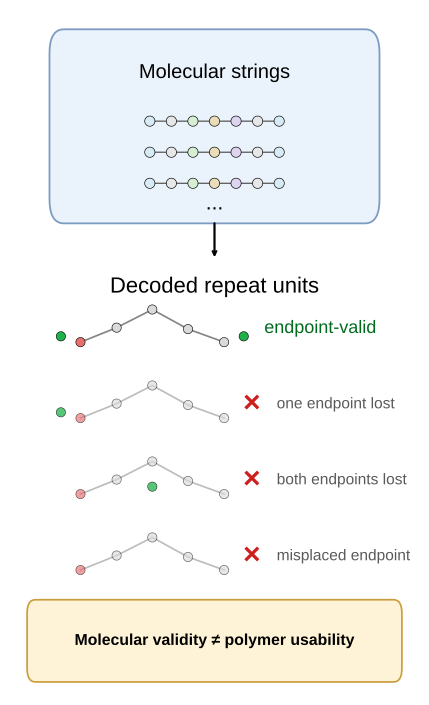

In [16]:
export_final_outputs_and_display_svg("Fig1B")

## Fig2

### Actual plotting code from `plot.ipynb` Cell 7

In [17]:
# Cell 8. Raw training-label distribution and ECDF
# Paper-style two-panel figure without in-panel titles.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: publication-friendly PDF font handling
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

if "ROOT" not in globals():
    ROOT = Path.cwd()

if "REF_CSV" not in globals():
    REF_CSV = ROOT / "MY_PAPER_RELATED" / "polybert_con" / "simulation-trajectory-aggregate.csv"

if "assert_exists" in globals():
    assert_exists(REF_CSV)
elif not REF_CSV.exists():
    raise FileNotFoundError(f"Missing required file: {REF_CSV}")


def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_panel_label(ax, label):
    ax.text(
        -0.10,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="right",
        va="bottom",
    )


FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

raw_label_df = pd.read_csv(REF_CSV).copy()

conductivity_col = next(
    (
        col for col in [
            "CONDUCTIVITY",
            "conductivity",
            "conductivity_S_cm",
            "sigma_S_cm",
        ]
        if col in raw_label_df.columns
    ),
    None,
)

if conductivity_col is None:
    raise ValueError(f"Could not find a conductivity column in {REF_CSV.name}.")

raw_sigma = pd.to_numeric(raw_label_df[conductivity_col], errors="coerce").dropna()
raw_sigma = raw_sigma.loc[raw_sigma.gt(0)]

if raw_sigma.empty:
    raise ValueError("No positive conductivity values found for raw training-label plotting.")

log10_sigma = np.log10(raw_sigma.to_numpy())

log10_sigma_sorted = np.sort(log10_sigma)
ecdf_y = np.arange(1, len(log10_sigma_sorted) + 1) / len(log10_sigma_sorted)

sigma_lower_log10 = -4.5
threshold_log10 = np.log10(1e-4)
sigma_top_log10 = -3.125

reference_lines = [
    ("sigma_lower", sigma_lower_log10, "#e84a4a", r"$\sigma_{\mathrm{lower}}$"),
    ("threshold", threshold_log10, "#f28e2b", r"$10^{-4}$ threshold"),
    ("sigma_top", sigma_top_log10, "#43a047", r"$\sigma_{\mathrm{top}}$"),
]

x_min = min(log10_sigma.min(), sigma_lower_log10) - 0.20
x_max = max(log10_sigma.max(), sigma_top_log10) + 0.22

line_label_fontsize = 11.0


def add_reference_lines(ax, panel):
    for key, x_value, color, label in reference_lines:
        ax.axvline(x_value, color=color, lw=1.45, zorder=2)

        if panel == "histogram":
            text_x = x_value - 0.015
            label_y = 0.96
            ha = "right"
            va = "top"

            if key == "threshold":
                text_x = x_value + 0.015
                ha = "left"

        elif panel == "ecdf":
            text_x = x_value - 0.015
            label_y = 0.23 if key in {"sigma_lower", "sigma_top"} else 0.07
            ha = "right"
            va = "bottom"

        else:
            raise ValueError(f"Unknown panel type: {panel}")

        ax.text(
            text_x,
            label_y,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            color=color,
            fontsize=line_label_fontsize,
            ha=ha,
            va=va,
        )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.05),
    gridspec_kw={"wspace": 0.28},
)

fig.patch.set_facecolor("white")

# Panel A: raw training-label distribution
ax = axes[0]

ax.hist(
    log10_sigma,
    bins=32,
    color="#4c78a8",
    edgecolor="white",
    linewidth=0.55,
    alpha=0.90,
)

add_reference_lines(ax, panel="histogram")

ax.set_xlim(x_min, x_max)
ax.set_xlabel(r"log$_{10}$ conductivity / S cm$^{-1}$", fontsize=10.0)
ax.set_ylabel("Count", fontsize=10.0)
ax.tick_params(axis="both", labelsize=8.8)
ax.grid(False)

add_panel_label(ax, "A")
despine(ax)

# Panel B: raw training-label ECDF
ax = axes[1]

ax.plot(
    log10_sigma_sorted,
    ecdf_y,
    color="#4c78a8",
    lw=1.65,
)

add_reference_lines(ax, panel="ecdf")

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel(r"log$_{10}$ conductivity / S cm$^{-1}$", fontsize=10.0)
ax.set_ylabel("ECDF", fontsize=10.0)
ax.tick_params(axis="both", labelsize=8.8)
ax.grid(False)

add_panel_label(ax, "B")
despine(ax)

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.18,
    top=0.92,
    wspace=0.30,
)

raw_dist_jpeg_path = FIGURE_DIR / "Figure_raw_training_label_distribution_ecdf.jpeg"
raw_dist_pdf_path = FIGURE_DIR / "Figure_raw_training_label_distribution_ecdf.pdf"
raw_dist_tif_path = FIGURE_DIR / "Figure_raw_training_label_distribution_ecdf.tif"
raw_dist_svg_path = FIGURE_DIR / "Figure_raw_training_label_distribution_ecdf.svg"
fig.savefig(
    raw_dist_jpeg_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    pil_kwargs={"quality": 95, "subsampling": 0},
)

fig.savefig(
    raw_dist_pdf_path,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    raw_dist_tif_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    pil_kwargs={"compression": "tiff_lzw"},
)

fig.savefig(raw_dist_svg_path, bbox_inches="tight")

print("Raw training labels:", len(log10_sigma))
print("Conductivity column:", conductivity_col)
print("Saved:", raw_dist_jpeg_path)
print("Saved:", raw_dist_pdf_path)
print("Saved:", raw_dist_tif_path)

plt.show()

Raw training labels: 6270
Conductivity column: CONDUCTIVITY
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_raw_training_label_distribution_ecdf.jpeg
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_raw_training_label_distribution_ecdf.pdf
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_raw_training_label_distribution_ecdf.tif


Fig2: figures/Fig2.svg | figures/Fig2.tif


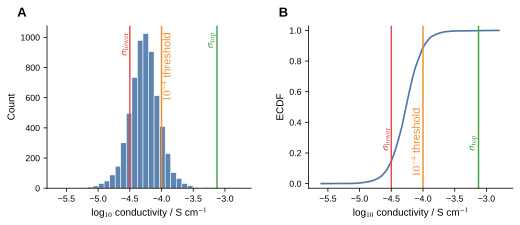

In [18]:
export_final_outputs_and_display_svg("Fig2")

## Fig6

### Actual plotting code from `plot.ipynb` Cell 4

In [19]:
# Cell 5. Figure 3 for Results
# A Endpoint-aware filtering summary
# B ANU yield under top-tail scalar conditioning
# C Distributional fidelity versus usable novelty
# D Surrogate-predicted enrichment for the proposed model

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.6, 6.9),
    gridspec_kw={"width_ratios": [1.0, 1.12], "height_ratios": [0.92, 1.08]},
)
axes = axes.ravel()
fig.patch.set_facecolor("white")

def add_panel_label(ax, label):
    ax.text(
        -0.11,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="right",
        va="bottom",
    )

def short_model_label(model_key):
    return FIG3_MODEL_LABELS[model_key]

FIG3_MODEL_ORDER = [
    "TransCVAE",
    "TransCVAE_PSMILES",
    "minGPT",
    "LSTM_CVAE",
    "LSTM_CVAE_PSMILES",
    "Encoder_Only",
    "Encoder_Only_PSMILES",
]

FIG3_MODEL_LABELS = {
    "TransCVAE": "Proposed",
    "TransCVAE_PSMILES": "PSMILES TransCVAE",
    "minGPT": "minGPT",
    "LSTM_CVAE": "SELFIES LSTM-CVAE",
    "LSTM_CVAE_PSMILES": "PSMILES LSTM-CVAE",
    "Encoder_Only": "SELFIES Encoder-only",
    "Encoder_Only_PSMILES": "PSMILES Encoder-only",
}

FIG3_MODEL_COLORS = {
    "TransCVAE": MODEL_COLORS["SELFIES-PSMILES TransCVAE"],
    "TransCVAE_PSMILES": MODEL_COLORS["PSMILES TransCVAE"],
    "minGPT": MODEL_COLORS["minGPT"],
    "LSTM_CVAE": "#d62728",
    "LSTM_CVAE_PSMILES": MODEL_COLORS["PSMILES LSTM-CVAE"],
    "Encoder_Only": "#2ca02c",
    "Encoder_Only_PSMILES": "#9467bd",
}

fig3_df = score.loc[score["condition"].isin(["LOW", "HIGH"])].copy()
fig3_df["target_setting"] = fig3_df["condition"].map(TARGET_MAP)
fig3_df = fig3_df.rename(columns={
    "all_novel_unique_mean": "anu_yield",
    "fcd_mean": "fcd",
    "hit_1e4_mean": "hit_fraction",
})
fig3_df = fig3_df[
    ["model", "condition", "target_setting", "anu_yield", "fcd", "hit_fraction"]
].copy()
fig3_df["model_order"] = fig3_df["model"].map({m: i for i, m in enumerate(FIG3_MODEL_ORDER)})
fig3_df["target_order"] = fig3_df["target_setting"].map({"lower target": 0, "top-tail target": 1})
fig3_df = fig3_df.sort_values(["model_order", "target_order"]).reset_index(drop=True)

if len(fig3_df) != 14:
    raise ValueError(f"Expected 14 Figure 3 points, got {len(fig3_df)}")

model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FIG3_MODEL_COLORS[m],
        markeredgecolor="black",
        markeredgewidth=0.35,
        label=FIG3_MODEL_LABELS[m],
        markersize=5.2,
    )
    for m in FIG3_MODEL_ORDER
]

target_handles = [
    Line2D(
        [0], [0],
        marker=TARGET_MARKERS[t],
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.7,
        label=t,
        markersize=5.2,
    )
    for t in ["lower target", "top-tail target"]
]

# -------------------------
# Panel A: Endpoint-aware filtering summary
# -------------------------
ax = axes[0]
ax.set_facecolor("white")

retained = 5487
excluded = 14513
total = 20000
retained_percent = retained / total
excluded_percent = excluded / total

ax.barh(
    [0],
    [retained],
    color=MODEL_COLORS["SELFIES-PSMILES TransCVAE"],
    edgecolor="black",
    linewidth=0.65,
    height=0.32,
)
ax.barh(
    [0],
    [excluded],
    left=[retained],
    color="#c9c9c9",
    edgecolor="black",
    linewidth=0.65,
    height=0.32,
)

ax.text(
    retained / 2,
    0,
    f"Retained\n{retained:,}\n{retained_percent:.1%}",
    ha="center",
    va="center",
    fontsize=7.5,
    color="white",
    fontweight="bold",
)
ax.text(
    retained + excluded / 2,
    0,
    f"Excluded\n{excluded:,}\n{excluded_percent:.1%}",
    ha="center",
    va="center",
    fontsize=7.5,
    color="black",
)

ax.text(
    0.02,
    0.16,
    "Exact two-endpoint reconstruction: 1.000\nEndpoint-pair accuracy: 0.9706",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.0,
)

ax.set_title("Endpoint-aware filtering summary", fontsize=10.5, pad=8)
ax.set_xlim(0, total)
ax.set_ylim(-0.50, 0.62)
ax.set_yticks([])
ax.tick_params(axis="y", left=False, labelleft=False)
ax.set_xticks([0, 10000, 20000])
ax.set_xlabel("Generated endpoint strings", fontsize=9.5)
add_panel_label(ax, "A")
despine(ax)
ax.spines["left"].set_visible(False)

# -------------------------
# Panel B: ANU yield under top-tail scalar conditioning
# -------------------------
ax = axes[1]
ax.set_facecolor("white")

top_tail_df = fig3_df.loc[fig3_df["target_setting"].eq("top-tail target")].copy()
top_tail_df = top_tail_df.sort_values("anu_yield", ascending=False).reset_index(drop=True)
y_pos = np.arange(len(top_tail_df))

for y, (_, row) in zip(y_pos, top_tail_df.iterrows()):
    color = FIG3_MODEL_COLORS[row["model"]]
    ax.barh(
        y,
        row["anu_yield"] - 1,
        left=1,
        height=0.42,
        color=color,
        edgecolor="black",
        linewidth=0.45,
        alpha=0.92,
    )

ax.set_xscale("log")
ax.set_xlim(5, 8e4)
ax.set_xticks([10, 100, 1000, 10000])
ax.set_yticks(y_pos)
ax.set_yticklabels([short_model_label(m) for m in top_tail_df["model"]], fontsize=8.0)
ax.invert_yaxis()
ax.set_title("ANU yield under top-tail scalar conditioning", fontsize=10.5, pad=8)
ax.set_xlabel("ANU yield, top-tail target", fontsize=9.5)
ax.set_ylabel("")
add_panel_label(ax, "B")
despine(ax)

# -------------------------
# Panel C: Distributional fidelity versus usable novelty
# -------------------------
ax = axes[2]
ax.set_facecolor("white")

for _, row in fig3_df.iterrows():
    is_proposed = row["model"] == "TransCVAE"
    ax.scatter(
        row["fcd"],
        row["anu_yield"],
        s=26 if is_proposed else 8,
        marker=TARGET_MARKERS[row["target_setting"]],
        color=FIG3_MODEL_COLORS[row["model"]],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.95,
        zorder=6 if is_proposed else 4,
    )

ax.set_yscale("log")
ax.set_xlim(0, 29)
ax.set_ylim(5, 8e4)
ax.set_title("Distributional fidelity versus usable novelty", fontsize=10.5, pad=8)
ax.set_xlabel("FCD", fontsize=9.5)
ax.set_ylabel("ANU yield", fontsize=9.5)
add_panel_label(ax, "C")
despine(ax)

# -------------------------
# Panel D: Surrogate-predicted enrichment
# -------------------------
ax = axes[3]
ax.set_facecolor("white")

score_hit = (
    tradeoff_df[tradeoff_df["display_model"].eq("SELFIES-PSMILES TransCVAE")]
    .set_index("target_setting")["hit_fraction"]
    .to_dict()
)
target_order = ["lower target", "top-tail target"]

raw_prediction_arrays_available = (
    "pred_pool_df" in globals()
    and {"target_setting", "pred_log10_sigma"}.issubset(pred_pool_df.columns)
    and pred_pool_df["pred_log10_sigma"].notna().any()
)

if raw_prediction_arrays_available:
    violin_data = [
        pred_pool_df.loc[pred_pool_df["target_setting"].eq(t), "pred_log10_sigma"].dropna().to_numpy()
        for t in target_order
    ]
    positions = np.arange(len(target_order))

    parts = ax.violinplot(
        violin_data,
        positions=positions,
        widths=0.62,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body in parts["bodies"]:
        body.set_facecolor(MODEL_COLORS["SELFIES-PSMILES TransCVAE"])
        body.set_edgecolor("black")
        body.set_alpha(0.90)
        body.set_linewidth(0.8)

    for i, vals in enumerate(violin_data):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        lo, hi = np.percentile(vals, [5, 95])
        mean = np.mean(vals)
        ax.plot([i, i], [lo, hi], color="black", lw=0.8, zorder=3)
        ax.add_patch(
            plt.Rectangle(
                (i - 0.085, q1),
                0.17,
                q3 - q1,
                facecolor="white",
                edgecolor="black",
                lw=0.8,
                zorder=4,
            )
        )
        ax.plot([i - 0.22, i + 0.22], [med, med], color="black", lw=1.0, zorder=5)
        ax.scatter(i, mean, s=18, facecolor="white", edgecolor="black", linewidth=0.8, zorder=6)

    ax.axhline(-4.0, color="black", lw=0.9, ls=(0, (4, 3)))
    ax.text(
        1.04,
        -4.13,
        "$10^{-4}$ S cm$^{-1}$",
        ha="left",
        va="top",
        fontsize=7.7,
    )
    ax.set_ylabel(r"Predicted log$_{10}$($\sigma$ / S cm$^{-1}$)", fontsize=9.5)
    ax.set_ylim(-6, -2)
else:
    hit_values = [score_hit[t] for t in target_order]
    ax.bar(
        np.arange(len(target_order)),
        hit_values,
        color=MODEL_COLORS["SELFIES-PSMILES TransCVAE"],
        edgecolor="black",
        linewidth=0.7,
        width=0.58,
    )
    ax.text(
        0.02,
        0.94,
        "Threshold: $10^{-4}$ S cm$^{-1}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.0,
    )
    ax.set_ylabel("Hit fraction above threshold", fontsize=9.5)
    ax.set_ylim(0, 1.08)

ax.set_title("Surrogate-predicted enrichment", fontsize=10.5, pad=8)
ax.set_xticks(np.arange(len(target_order)))
ax.set_xticklabels(
    [f"{t}\nHit = {score_hit[t]:.4f}" for t in target_order],
    fontsize=8.3,
)
ax.set_xlabel("")
add_panel_label(ax, "D")
despine(ax)

fig.legend(
    handles=model_handles + target_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=5,
    frameon=True,
    edgecolor="black",
    fontsize=6.5,
    columnspacing=1.0,
    handletextpad=0.45,
)

fig.tight_layout(w_pad=2.2, h_pad=2.1, rect=(0.0, 0.12, 1.0, 1.0))

jpeg_path = FIGURE_DIR / "Figure3_generated_pool_enrichment.jpeg"
pdf_path = FIGURE_DIR / "Figure3_generated_pool_enrichment.pdf"
tif_path = FIGURE_DIR / "Figure3_generated_pool_enrichment.tif"
svg_path = FIGURE_DIR / "Figure3_generated_pool_enrichment.svg"

fig.savefig(
    jpeg_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    pil_kwargs={"quality": 95, "subsampling": 0},
)
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
fig.savefig(tif_path, dpi=600, bbox_inches="tight", facecolor="white", pil_kwargs={"compression": "tiff_lzw"})
fig.savefig(svg_path, bbox_inches="tight")

print("Figure 3 points:", len(fig3_df))
print("Saved:", jpeg_path)
print("Saved:", pdf_path)
print("Saved:", tif_path)

plt.show()


Figure 3 points: 14
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure3_generated_pool_enrichment.jpeg
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure3_generated_pool_enrichment.pdf
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure3_generated_pool_enrichment.tif


Fig6: figures/Fig6.svg | figures/Fig6.tif


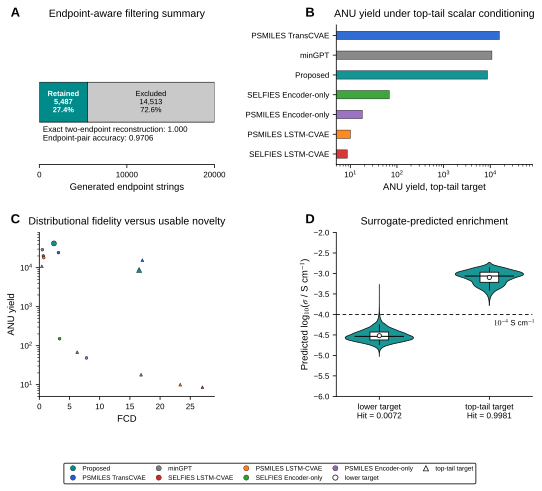

In [20]:
export_final_outputs_and_display_svg("Fig6")

## Fig7

### Actual plotting code from `scripts/figures`

Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Fig7.svg
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Fig7.tif
Panel C source: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/MODELS/FCD_runs/_conductivity_eval/conductivity_eval_summary.csv lower=0.007201 top-tail=0.998098
Fig7: figures/Fig7.svg | figures/Fig7.tif


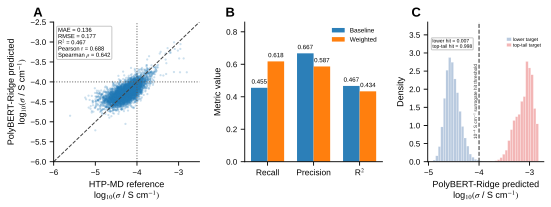

In [21]:
from scripts.figures.make_fig7_surrogate_reliability import main as make_fig7
make_fig7()
display_generated_svg("Fig7")

## Fig8

### Actual plotting code from `scripts/figures`

Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Fig8.svg
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Fig8.tif
Source: /home/user/바탕화면/DL/gromacs/eval_top10_bottom10_stratified100/results/cne0_correction_method_sweep_ref/cne0_correction_per_sample.csv filter=cutoff_source:rdf_min,method_id:4,method:coordination_state_filter
Stats: completed=108/120 MALogE=0.328990 median_shift=2.240312
Fig8: figures/Fig8.svg | figures/Fig8.tif


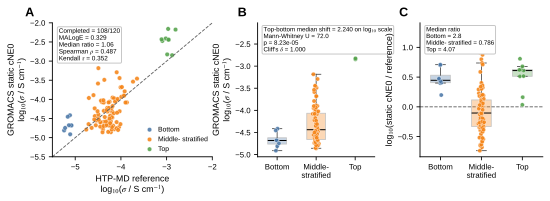

In [22]:
from scripts.figures.make_fig8_reference_stratified_static_cne0 import main as make_fig8
make_fig8()
display_generated_svg("Fig8")

## Fig9

### Actual plotting code from `plot.ipynb` Cell 6

In [23]:
# Cell 7. Candidate-level MD reassessment and surrogate-vs-MD check
# Expanded 60-candidate / 6-group static cNE0 reassessment.
# Data source and definitions follow:
# MY_PAPER_RELATED/gromacs_eval_pred_conductivity/github_results/latest_notebook_manifest_60/
# reassessment_experimental_results_60candidate.md

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "ROOT" not in globals():
    ROOT = Path.cwd()

if "despine" not in globals():
    def despine(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RUN_RESULTS_CSV = (
    ROOT / "MY_PAPER_RELATED" / "gromacs_eval_pred_conductivity"
    / "github_results" / "latest_notebook_manifest_60" / "run_results.csv"
)
assert_exists(RUN_RESULTS_CSV) if "assert_exists" in globals() else None
if not RUN_RESULTS_CSV.exists():
    raise FileNotFoundError(f"Missing required 60-candidate reassessment file: {RUN_RESULTS_CSV}")

run_df = pd.read_csv(RUN_RESULTS_CSV).copy()
required_cols = {
    "Trajectory ID",
    "sample_group",
    "status",
    "md_status",
    "analysis_status",
    "analysis_replica_success_count",
    "CONDUCTIVITY",
    "sigma_cNE_htpmd_S_cm_mean_pred",
    "sigma_cNE_htpmd_S_cm_std_pred",
}
missing = required_cols - set(run_df.columns)
if missing:
    raise ValueError(f"Missing required 60-candidate reassessment columns: {missing}")

for status_col in ["status", "md_status", "analysis_status"]:
    bad = run_df.loc[~run_df[status_col].eq("ok"), ["Trajectory ID", "sample_group", status_col]]
    if not bad.empty:
        raise ValueError(f"Non-ok rows found in {status_col}:\n{bad.to_string(index=False)}")

md_df = run_df[
    [
        "Trajectory ID",
        "sample_group",
        "CONDUCTIVITY",
        "sigma_cNE_htpmd_S_cm_mean_pred",
        "sigma_cNE_htpmd_S_cm_std_pred",
        "analysis_replica_success_count",
    ]
].copy()

md_df = md_df.rename(
    columns={
        "CONDUCTIVITY": "polybert_pred_cond_S_cm",
        "sigma_cNE_htpmd_S_cm_mean_pred": "md_static_cNE0_S_cm",
        "sigma_cNE_htpmd_S_cm_std_pred": "md_static_cNE0_std_S_cm",
        "analysis_replica_success_count": "n_replicas",
    }
)

for col in ["polybert_pred_cond_S_cm", "md_static_cNE0_S_cm", "md_static_cNE0_std_S_cm", "n_replicas"]:
    md_df[col] = pd.to_numeric(md_df[col], errors="coerce")

md_df = md_df.dropna(subset=["sample_group", "polybert_pred_cond_S_cm", "md_static_cNE0_S_cm"]).copy()
md_df = md_df.loc[md_df["polybert_pred_cond_S_cm"].gt(0) & md_df["md_static_cNE0_S_cm"].gt(0)].copy()
md_df["Trajectory ID"] = md_df["Trajectory ID"].astype(int)
md_df["log10_polybert_pred_cond"] = np.log10(md_df["polybert_pred_cond_S_cm"])
md_df["log10_md_static_cNE0"] = np.log10(md_df["md_static_cNE0_S_cm"])

md_group_order = [
    "HIGH_top",
    "HIGH_middle_stratified",
    "HIGH_bottom",
    "LOW_top",
    "LOW_middle_stratified",
    "LOW_bottom",
]
md_group_labels = {
    "HIGH_top": "TT-top",
    "HIGH_middle_stratified": "TT-middle",
    "HIGH_bottom": "TT-bottom",
    "LOW_top": "LT-top",
    "LOW_middle_stratified": "LT-middle",
    "LOW_bottom": "LT-bottom",
}
md_group_colors = {
    "HIGH_top": "#1f5b95",
    "HIGH_middle_stratified": "#4c78a8",
    "HIGH_bottom": "#8fb7dd",
    "LOW_top": "#c64616",
    "LOW_middle_stratified": "#e67e22",
    "LOW_bottom": "#f2a51a",
}

missing_groups = sorted(set(md_group_order) - set(md_df["sample_group"]))
if missing_groups:
    raise ValueError(f"Missing expected 60-candidate sample groups: {missing_groups}")

extra_groups = sorted(set(md_df["sample_group"]) - set(md_group_order))
if extra_groups:
    raise ValueError(f"Unexpected sample groups in 60-candidate reassessment: {extra_groups}")

if len(md_df) != 60:
    raise ValueError(f"Expected 60 candidate-level rows, got {len(md_df)}")

group_counts = md_df.groupby("sample_group")["Trajectory ID"].nunique().reindex(md_group_order)
if not group_counts.eq(10).all():
    raise ValueError(f"Expected 10 candidates per group, got:\n{group_counts.to_string()}")

if not md_df["n_replicas"].eq(3).all():
    replica_counts = md_df.groupby("sample_group")["n_replicas"].value_counts(dropna=False)
    raise ValueError(f"Expected 3 successful replicas per candidate, got:\n{replica_counts.to_string()}")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.8, 3.25),
    gridspec_kw={"wspace": 0.24},
)
fig.patch.set_facecolor("white")
y_col = "log10_md_static_cNE0"
x_col = "log10_polybert_pred_cond"
y_label = r"GROMACS static cNE0 log$_{10}$($\sigma$ / S cm$^{-1}$)"


def add_outer_panel_label(ax, label):
    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

# Panel A: candidate-level static cNE0 reassessment by selected pool.
ax = axes[0]
for xpos, group in enumerate(md_group_order):
    sub = md_df.loc[md_df["sample_group"].eq(group)].sort_values(y_col).copy()
    offsets = np.linspace(-0.16, 0.16, len(sub)) if len(sub) > 1 else np.array([0.0])
    ax.scatter(
        np.full(len(sub), xpos) + offsets,
        sub[y_col],
        s=18,
        facecolor=md_group_colors[group],
        edgecolor="black",
        linewidth=0.30,
        alpha=0.95,
        zorder=3,
    )
    mean_y = sub[y_col].mean()
    ax.plot([xpos - 0.23, xpos + 0.23], [mean_y, mean_y], color="black", lw=1.05, zorder=4)

ax.axhline(-4.0, color="0.50", lw=0.8, ls=(0, (4, 2)), zorder=1)
ax.set_xlim(-0.45, len(md_group_order) - 0.55)
ax.set_ylim(-6.5, -2.3)
ax.set_xticks(np.arange(len(md_group_order)))
ax.set_xticklabels([md_group_labels[g] for g in md_group_order], fontsize=8.0, rotation=28, ha="right")
ax.set_yticks(np.arange(-6.0, -2.0, 0.5))
ax.set_ylabel(y_label, fontsize=9.5)
add_outer_panel_label(ax, "A")
despine(ax)

# Panel B: surrogate-vs-MD agreement for the same 60 candidates.
ax = axes[1]
for group in md_group_order:
    sub = md_df.loc[md_df["sample_group"].eq(group)].copy()
    ax.scatter(
        sub[x_col],
        sub[y_col],
        s=20,
        facecolor=md_group_colors[group],
        edgecolor="black",
        linewidth=0.30,
        alpha=0.95,
        label=md_group_labels[group],
        zorder=3,
    )

axis_min = min(md_df[x_col].min(), md_df[y_col].min()) - 0.12
axis_max = max(md_df[x_col].max(), md_df[y_col].max()) + 0.12
ax.plot([axis_min, axis_max], [axis_min, axis_max], color="0.55", lw=0.8, ls=(0, (3, 2)), zorder=1)
ax.set_xlim(-6.5, -2.25)
ax.set_ylim(-6.5, -2.3)
ax.set_xticks([-6, -5, -4, -3])
ax.set_yticks(np.arange(-6.0, -2.0, 0.5))
ax.set_xlabel(r"PolyBERT-Ridge predicted log$_{10}$($\sigma$ / S cm$^{-1}$)", fontsize=9.5)
ax.set_ylabel(y_label, fontsize=9.5)
add_outer_panel_label(ax, "B")
ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=6.5,
    handletextpad=0.30,
    borderaxespad=0.20,
    ncol=2,
    columnspacing=0.80,
)
despine(ax)

fig.subplots_adjust(left=0.085, right=0.985, bottom=0.22, top=0.92, wspace=0.28)

md_jpeg_path = FIGURE_DIR / "Figure_MD_reassessment_surrogate_vs_md.jpeg"
md_pdf_path = FIGURE_DIR / "Figure_MD_reassessment_surrogate_vs_md.pdf"
md_tif_path = FIGURE_DIR / "Figure_MD_reassessment_surrogate_vs_md.tif"
md_svg_path = FIGURE_DIR / "Figure_MD_reassessment_surrogate_vs_md.svg"
fig.savefig(
    md_jpeg_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    pil_kwargs={"quality": 95, "subsampling": 0},
)
fig.savefig(md_pdf_path, bbox_inches="tight", facecolor="white")
fig.savefig(md_tif_path, dpi=600, bbox_inches="tight", facecolor="white", pil_kwargs={"compression": "tiff_lzw"})
fig.savefig(md_svg_path, bbox_inches="tight")
print("MD reassessment candidates:", len(md_df))
print("Groups:", len(md_group_order))
print("Candidates per group:")
print(group_counts.rename(index=md_group_labels).to_string())
print("Replicas per candidate:", int(md_df["n_replicas"].iloc[0]))
print("Data source:", RUN_RESULTS_CSV)
print("Saved:", md_jpeg_path)
print("Saved:", md_pdf_path)
print("Saved:", md_tif_path)

plt.show()


MD reassessment candidates: 60
Groups: 6
Candidates per group:
sample_group
TT-top       10
TT-middle    10
TT-bottom    10
LT-top       10
LT-middle    10
LT-bottom    10
Replicas per candidate: 3
Data source: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/MY_PAPER_RELATED/gromacs_eval_pred_conductivity/github_results/latest_notebook_manifest_60/run_results.csv
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_MD_reassessment_surrogate_vs_md.jpeg
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_MD_reassessment_surrogate_vs_md.pdf
Saved: /home/user/바탕화면/DL/SPE-DESIGN-PIPELINE/figures/Figure_MD_reassessment_surrogate_vs_md.tif


Fig9: figures/Fig9.svg | figures/Fig9.tif


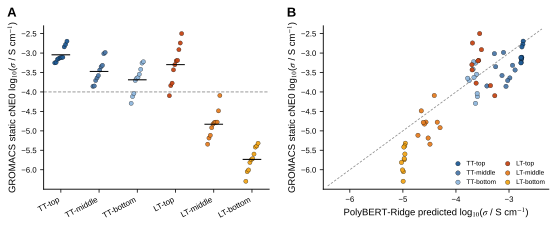

In [24]:
export_final_outputs_and_display_svg("Fig9")